# Modelagem e avaliacao temporal

Este notebook compara modelos de regressao para estimar o preco de imoveis. A analise usa uma separacao temporal, validacao com janelas expansivas e um conjunto de teste formado pelas datas mais recentes. Os resultados sao medidos na escala original de dolares.

## 1. Preparacao dos dados

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.inspection import permutation_importance

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data/raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from property_value_insights.data_contract import (  # noqa: E402
    load_raw_data,
)
from property_value_insights.eda import (  # noqa: E402
    merge_historical_with_demographics,
)
from property_value_insights.modeling import (  # noqa: E402
    build_estimator,
    cross_validate_median_baseline,
    cross_validate_temporal,
    feature_columns,
    fit_and_evaluate,
    median_baseline_prediction,
    regression_metrics,
    segment_metrics,
    select_temporal_candidates,
    summarize_temporal_validation,
    temporal_train_test_split,
)

FIGURE_DIR = PROJECT_ROOT / "reports/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
N_SPLITS = 5
SELECTION_TOLERANCE = 0.005
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


In [2]:
historical, demographics, future = load_raw_data(PROJECT_ROOT / "data/raw")
merged, merge_audit = merge_historical_with_demographics(historical, demographics)

dataset_summary = pd.DataFrame(
    [
        {"dataset": "historical", "rows": len(historical), "columns": len(historical.columns)},
        {
            "dataset": "demographics",
            "rows": len(demographics),
            "columns": len(demographics.columns),
        },
        {"dataset": "future", "rows": len(future), "columns": len(future.columns)},
        {"dataset": "merged_historical", "rows": len(merged), "columns": len(merged.columns)},
    ]
)
display(dataset_summary)
display(
    pd.DataFrame(
        [{
            "historical_rows": merge_audit.historical_rows,
            "merged_rows": merge_audit.merged_rows,
            "zipcode_coverage_pct": merge_audit.zipcode_coverage_pct,
            "unmatched_rows": merge_audit.unmatched_rows,
        }]
    )
)


,dataset,rows,columns
0,historical,21613,21
1,demographics,70,27
2,future,100,18
3,merged_historical,21613,47


,historical_rows,merged_rows,zipcode_coverage_pct,unmatched_rows
0,21613,21613,100.0000,0


## 2. Protocolo de avaliacao

- As datas sao ordenadas antes da divisao.
- As datas mais recentes formam o teste temporal e nao participam da busca.
- A validacao usa cinco janelas temporais expansivas no conjunto de desenvolvimento.
- O `id` e excluido das features e o `zipcode` e tratado como categoria.
- Os dados demograficos sao comparados por ablation.
- A busca e pequena, deterministica e usa os mesmos folds para todos os candidatos.
- MAE e RMSE em dolares sao as metricas principais; RMSLE e R2 complementam a analise.

A transformacao `log1p(price)` e avaliada na escala original de dolares. Somente o champion e a referencia de mediana sao medidos no teste temporal depois da selecao.


In [3]:
split = temporal_train_test_split(merged, test_size=0.2)
split_summary = pd.DataFrame(
    [{
        "development_rows": len(split.train),
        "test_rows": len(split.test),
        "development_end": split.train_end.date(),
        "test_start": split.test_start.date(),
        "test_share": len(split.test) / len(merged),
    }]
)
display(split_summary)


,development_rows,test_rows,development_end,test_start,test_share
0,16973,4640,2015-03-03,2015-03-04,0.2147


## 3. Candidatos e conjuntos de features

In [4]:
candidates = [
    {
        "candidate": "baseline_median",
        "model_name": None,
        "feature_set": "physical",
        "target_transform": "raw",
        "model_params": {},
    },
    {
        "candidate": "ridge_physical_raw",
        "model_name": "ridge",
        "feature_set": "physical",
        "target_transform": "raw",
        "model_params": {},
    },
    {
        "candidate": "ridge_physical_log",
        "model_name": "ridge",
        "feature_set": "physical",
        "target_transform": "log",
        "model_params": {},
    },
    {
        "candidate": "ridge_demographics_raw",
        "model_name": "ridge",
        "feature_set": "with_demographics",
        "target_transform": "raw",
        "model_params": {},
    },
    {
        "candidate": "ridge_demographics_log",
        "model_name": "ridge",
        "feature_set": "with_demographics",
        "target_transform": "log",
        "model_params": {},
    },
    {
        "candidate": "hist_physical_raw",
        "model_name": "hist_gradient_boosting",
        "feature_set": "physical",
        "target_transform": "raw",
        "model_params": {},
    },
    {
        "candidate": "hist_physical_log",
        "model_name": "hist_gradient_boosting",
        "feature_set": "physical",
        "target_transform": "log",
        "model_params": {},
    },
]

search_params = {
    "default": {},
    "regularized": {
        "learning_rate": 0.04,
        "max_iter": 500,
        "max_leaf_nodes": 31,
        "l2_regularization": 1.0,
    },
    "compact": {
        "learning_rate": 0.05,
        "max_iter": 400,
        "max_leaf_nodes": 15,
        "l2_regularization": 0.5,
    },
    "wide": {
        "learning_rate": 0.04,
        "max_iter": 400,
        "max_leaf_nodes": 63,
        "l2_regularization": 1.0,
    },
}

for target_transform in ["raw", "log"]:
    for label, model_params in search_params.items():
        candidates.append(
            {
                "candidate": f"hist_demographics_{target_transform}_{label}",
                "model_name": "hist_gradient_boosting",
                "feature_set": "with_demographics",
                "target_transform": target_transform,
                "model_params": model_params,
            }
        )

candidate_specs = {item["candidate"]: item for item in candidates}
display(
    pd.DataFrame(
        [
            {
                "candidate": item["candidate"],
                "model": item["model_name"] or "median",
                "features": item["feature_set"],
                "target": item["target_transform"],
                "parameters": item["model_params"],
            }
            for item in candidates
        ]
    )
)


,candidate,model,features,target,parameters
0,baseline_median,median,physical,raw,{}
1,ridge_physical_raw,ridge,physical,raw,{}
2,ridge_physical_log,ridge,physical,log,{}
3,ridge_demographics_raw,ridge,with_demographics,raw,{}
4,ridge_demographics_log,ridge,with_demographics,log,{}
5,hist_physical_raw,hist_gradient_boosting,physical,raw,{}
6,hist_physical_log,hist_gradient_boosting,physical,log,{}
7,hist_demographics_raw_default,hist_gradient_boosting,with_demographics,raw,{}
8,hist_demographics_raw_regularized,hist_gradient_boosting,with_demographics,raw,"{'learning_rate': 0.04, 'max_iter': 500, 'max_..."
9,hist_demographics_raw_compact,hist_gradient_boosting,with_demographics,raw,"{'learning_rate': 0.05, 'max_iter': 400, 'max_..."


## 4. Ajuste e comparacao

In [5]:
cv_results = {}

for item in candidates:
    name = item["candidate"]
    if item["model_name"] is None:
        cv = cross_validate_median_baseline(split.train, n_splits=N_SPLITS)
    else:
        estimator = build_estimator(
            item["model_name"],
            item["feature_set"],
            target_transform=item["target_transform"],
            model_params=item["model_params"],
        )
        cv = cross_validate_temporal(
            estimator,
            split.train,
            feature_set=item["feature_set"],
            n_splits=N_SPLITS,
        )
    cv_results[name] = cv

validation_results = summarize_temporal_validation(cv_results)
selection = select_temporal_candidates(
    validation_results,
    relative_tolerance=SELECTION_TOLERANCE,
)
champion_name = selection.champion
challenger_name = selection.challenger

decision_summary = validation_results.loc[
    validation_results["candidate"].isin([champion_name, challenger_name])
].copy()
decision_summary["role"] = decision_summary["candidate"].map(
    {champion_name: "champion", challenger_name: "challenger"}
)
decision_summary["role_order"] = decision_summary["role"].map(
    {"champion": 0, "challenger": 1}
)
decision_summary = (
    decision_summary.sort_values("role_order")
    .drop(columns="role_order")
    .reset_index(drop=True)
)
validation_schedule = cv_results[champion_name][
    [
        "fold",
        "train_end",
        "validation_start",
        "validation_end",
        "train_rows",
        "validation_rows",
    ]
]

display(validation_results)
display(decision_summary)
display(validation_schedule)

champion_spec = candidate_specs[champion_name]
champion_estimator = build_estimator(
    champion_spec["model_name"],
    champion_spec["feature_set"],
    target_transform=champion_spec["target_transform"],
    model_params=champion_spec["model_params"],
)
champion_evaluation = fit_and_evaluate(
    champion_estimator,
    split.train,
    split.test,
    feature_set=champion_spec["feature_set"],
)
baseline_predictions = median_baseline_prediction(split.train, split.test)
baseline_metrics = regression_metrics(split.test["price"], baseline_predictions)

holdout_results = pd.DataFrame(
    [
        {
            "candidate": "baseline_median",
            **baseline_metrics,
            "fit_seconds": 0.0,
        },
        {
            "candidate": champion_name,
            **champion_evaluation.metrics,
            "fit_seconds": champion_evaluation.fit_seconds,
        },
    ]
)
display(holdout_results)

baseline_row = holdout_results.loc[
    holdout_results["candidate"] == "baseline_median"
].iloc[0]
champion_row = holdout_results.loc[
    holdout_results["candidate"] == champion_name
].iloc[0]
comparison_rows = []
for metric in ["mae", "rmse", "rmsle"]:
    baseline_value = float(baseline_row[metric])
    champion_value = float(champion_row[metric])
    comparison_rows.append(
        {
            "metric": metric.upper(),
            "median_baseline": baseline_value,
            "champion": champion_value,
            "relative_reduction_pct": (
                (baseline_value - champion_value) / baseline_value * 100
            ),
            "absolute_change": champion_value - baseline_value,
        }
    )
comparison_rows.append(
    {
        "metric": "R2",
        "median_baseline": float(baseline_row["r2"]),
        "champion": float(champion_row["r2"]),
        "relative_reduction_pct": None,
        "absolute_change": float(champion_row["r2"] - baseline_row["r2"]),
    }
)
comparison = pd.DataFrame(comparison_rows)
comparison_display = comparison.copy()
for column in ["median_baseline", "champion", "absolute_change"]:
    comparison_display[column] = comparison_display[column].map(
        lambda value: f"{value:,.3f}"
    )
comparison_display["relative_reduction_pct"] = comparison[
    "relative_reduction_pct"
].map(lambda value: "-" if pd.isna(value) else f"{value:.1f}%")
mae_reduction_pct = comparison.loc[
    comparison["metric"] == "MAE", "relative_reduction_pct"
].iloc[0]
display(comparison_display)


,candidate,cv_mae_mean,cv_mae_std,cv_mae_worst,cv_rmse_mean,cv_rmsle_mean
0,hist_demographics_log_default,"63,128.3704","1,547.4509","65,603.1557","117,518.9681",0.1646
1,hist_demographics_log_regularized,"63,174.2804","1,498.9705","65,856.5398","118,599.3528",0.1645
2,hist_physical_log,"63,446.1268","1,987.5924","65,887.7911","119,528.9516",0.1657
3,hist_demographics_log_compact,"63,448.3591","1,591.9895","66,517.9838","118,678.3960",0.1639
4,hist_demographics_log_wide,"63,633.2437","1,509.3521","65,680.2564","120,067.4863",0.1657
5,hist_demographics_raw_regularized,"65,237.5699",918.7142,"66,324.7554","124,113.9242",0.1683
6,hist_demographics_raw_default,"65,281.6993",648.0453,"66,147.6701","123,517.2060",0.1688
7,hist_demographics_raw_wide,"65,555.9191","1,048.4151","66,842.9479","125,786.0201",0.1689
8,hist_demographics_raw_compact,"65,846.6189",687.6757,"66,844.2707","122,395.8574",0.1697
9,hist_physical_raw,"67,025.3673","2,115.7843","70,082.9783","127,212.9435",0.1719


,candidate,cv_mae_mean,cv_mae_std,cv_mae_worst,cv_rmse_mean,cv_rmsle_mean,role
0,hist_demographics_log_default,"63,128.3704","1,547.4509","65,603.1557","117,518.9681",0.1646,champion
1,hist_demographics_log_regularized,"63,174.2804","1,498.9705","65,856.5398","118,599.3528",0.1645,challenger


,fold,train_end,validation_start,validation_end,train_rows,validation_rows
0,1,2014-06-22,2014-06-23,2014-08-10,3235,3442
1,2,2014-08-10,2014-08-11,2014-09-28,6677,3058
2,3,2014-09-28,2014-09-29,2014-11-16,9735,2792
3,4,2014-11-16,2014-11-17,2015-01-10,12527,2392
4,5,2015-01-10,2015-01-12,2015-03-03,14919,2054


,candidate,mae,rmse,rmsle,r2,median_absolute_error,fit_seconds
0,baseline_median,"225,353.8853","382,414.5500",0.5250,-0.0790,"149,600.0000",0.0000
1,hist_demographics_log_default,"73,912.4389","129,023.8004",0.1818,0.8772,"44,598.5181",1.6196


,metric,median_baseline,champion,relative_reduction_pct,absolute_change
0,MAE,"225,353.885","73,912.439",67.2%,"-151,441.446"
1,RMSE,"382,414.550","129,023.800",66.3%,"-253,390.750"
2,RMSLE,0.525,0.182,65.4%,-0.343
3,R2,-0.079,0.877,-,0.956


## 5. Selecao e analise por segmentos

In [6]:
selection_summary = pd.DataFrame(
    [
        {
            "champion": champion_name,
            "challenger": challenger_name,
            "relative_tolerance_pct": selection.relative_tolerance * 100,
            "holdout_evaluated_candidates": "baseline_median, champion",
        }
    ]
)
display(selection_summary)

holdout = split.test.copy()
holdout["prediction"] = champion_evaluation.predictions.to_numpy()
holdout["price_band"] = pd.qcut(
    holdout["price"],
    q=4,
    duplicates="drop",
)
price_band_errors = segment_metrics(
    holdout["price"],
    holdout["prediction"],
    holdout["price_band"],
    segment_name="price_band",
)
zipcode_errors = segment_metrics(
    holdout["price"],
    holdout["prediction"],
    holdout["zipcode"],
    segment_name="zipcode",
).query("rows >= 20").sort_values("mae", ascending=False)

display(price_band_errors)
display(zipcode_errors.head(10))


,champion,challenger,relative_tolerance_pct,holdout_evaluated_candidates
0,hist_demographics_log_default,hist_demographics_log_regularized,0.5000,"baseline_median, champion"


,price_band,rows,mae,rmse,rmsle,r2,median_absolute_error
0,"(80999.999, 330000.0]",1169,"34,718.3413","46,205.4744",0.1834,0.1268,"27,079.2548"
1,"(330000.0, 464475.0]",1151,"48,118.6431","65,313.2064",0.1726,-1.9265,"38,344.9943"
2,"(464475.0, 655000.0]",1162,"60,778.7467","78,448.7494",0.1576,-1.0401,"49,763.9149"
3,"(655000.0, 5350000.0]",1158,"152,295.7803","232,664.6762",0.2096,0.7557,"102,986.0485"


,zipcode,rows,mae,rmse,rmsle,r2,median_absolute_error
48,98112,47,"222,327.6223","318,462.7445",0.2021,0.7582,"146,462.7430"
3,98004,63,"211,340.6284","304,483.1616",0.1674,0.8729,"151,312.7571"
25,98040,67,"173,003.4533","277,712.8471",0.1733,0.8057,"114,904.3256"
5,98006,98,"158,471.5146","308,897.8089",0.2023,0.7307,"74,071.1210"
43,98105,49,"145,311.0160","209,159.0806",0.1773,0.8963,"91,608.5333"
4,98005,33,"117,791.7413","153,387.9354",0.1822,0.7911,"87,099.8996"
69,98199,68,"117,488.9354","211,266.7098",0.1788,0.7701,"64,391.1484"
53,98119,36,"105,671.1052","139,581.0031",0.1639,0.6524,"80,388.6436"
21,98033,98,"105,584.1100","164,977.6846",0.1782,0.7951,"73,142.2201"
49,98115,135,"104,099.5692","144,588.7723",0.2163,0.5960,"70,957.0988"


## 6. Importancia das variaveis

In [7]:
selected_features = feature_columns(champion_spec["feature_set"])
importance_result = permutation_importance(
    champion_evaluation.estimator,
    split.test[selected_features],
    split.test["price"],
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
feature_importance = (
    pd.DataFrame(
        {
            "feature": selected_features,
            "mae_increase": importance_result.importances_mean,
            "mae_std": importance_result.importances_std,
        }
    )
    .sort_values("mae_increase", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance.head(15))


,feature,mae_increase,mae_std
0,sqft_living,"54,490.9428",275.2124
1,lat,"49,954.6948",626.7636
2,grade,"39,444.1408",691.4466
3,per_bchlr,"14,337.3724",103.2309
4,per_prfsnl,"12,852.8715",44.0214
5,hous_val_amt,"8,944.0977",299.4177
6,long,"8,171.3356",431.8931
7,sqft_lot,"7,974.3504",245.3867
8,view,"6,084.1555",145.5033
9,yr_built,"5,054.2873",203.1135


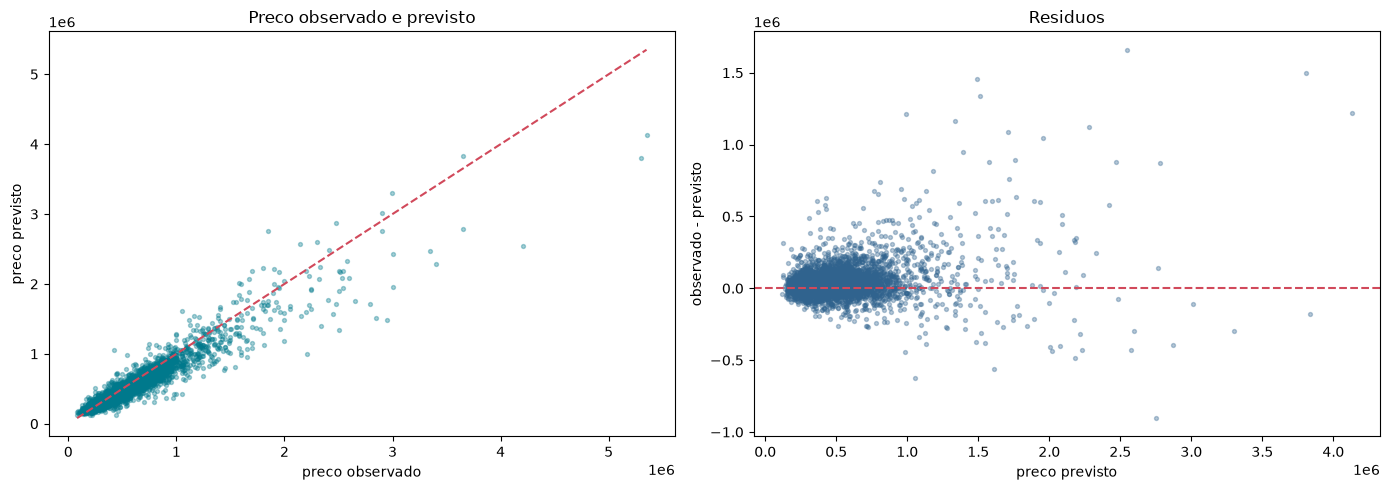

In [8]:
actual = split.test["price"].to_numpy()
predicted = champion_evaluation.predictions.to_numpy()
residuals = actual - predicted

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(actual, predicted, s=8, alpha=0.35, color="#00798c")
limits = [min(actual.min(), predicted.min()), max(actual.max(), predicted.max())]
axes[0].plot(limits, limits, linestyle="--", color="#d1495b")
axes[0].set_title("Preco observado e previsto")
axes[0].set_xlabel("preco observado")
axes[0].set_ylabel("preco previsto")

axes[1].scatter(predicted, residuals, s=8, alpha=0.35, color="#30638e")
axes[1].axhline(0, linestyle="--", color="#d1495b")
axes[1].set_title("Residuos")
axes[1].set_xlabel("preco previsto")
axes[1].set_ylabel("observado - previsto")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Registro dos resultados

In [9]:
report_path = PROJECT_ROOT / "reports/model_comparison.md"
report_lines = [
    "# Relatorio de modelagem e avaliacao",
    "",
    "## Protocolo",
    "",
    f"- Linhas de desenvolvimento: {len(split.train):,}.",
    f"- Linhas do teste temporal: {len(split.test):,}.",
    f"- Ultima data do desenvolvimento: {split.train_end.date()}.",
    f"- Primeira data do teste: {split.test_start.date()}.",
    "- Validacao: cinco janelas temporais expansivas com datas completas.",
    "- Busca: conjunto pequeno e deterministico de configuracoes.",
    "- Features demograficas: comparadas por ablation.",
    "- O id foi excluido das features e o zipcode foi tratado como categoria.",
    "- O teste temporal foi consultado somente apos a selecao.",
    "",
    "## Validacao temporal",
    "",
    validation_results.to_markdown(index=False, floatfmt=".3f"),
    "",
    "## Janelas temporais do champion",
    "",
    validation_schedule.to_markdown(index=False),
    "",
    "## Decisao do modelo",
    "",
    decision_summary.to_markdown(index=False, floatfmt=".3f"),
    "",
    (
        f"O champion `{champion_name}` foi escolhido entre os candidatos ate "
        f"{selection.relative_tolerance:.1%} da menor MAE media, priorizando "
        "o menor erro no pior fold e a menor variacao temporal."
    ),
    (
        f"O challenger `{challenger_name}` apresentou a menor MAE media entre "
        "os candidatos restantes e nao foi avaliado no teste temporal."
    ),
    "",
    "## Avaliacao temporal reservada",
    "",
    holdout_results.to_markdown(index=False, floatfmt=".3f"),
    "",
    "## Comparacao com a referencia",
    "",
    (
        "A versao inicial nao incluia um modelo preditivo. A mediana dos precos "
        "no conjunto de desenvolvimento e a referencia quantitativa."
    ),
    "",
    comparison_display.to_markdown(index=False),
    "",
    f"A MAE do champion foi reduzida em {mae_reduction_pct:.1f}%.",
    (
        f"O R2 passou de {baseline_row['r2']:.3f} na referencia para "
        f"{champion_row['r2']:.3f} no champion."
    ),
    "",
    "## Erro por faixa de preco",
    "",
    price_band_errors.to_markdown(index=False),
    "",
    "## Maiores erros por CEP",
    "",
    zipcode_errors.head(10).to_markdown(index=False),
    "",
    "## Variaveis com maior impacto na MAE",
    "",
    feature_importance.head(15).to_markdown(index=False),
    "",
    (
        "O desempenho deve ser interpretado junto com a distribuicao temporal, "
        "as faixas de preco e a cobertura dos CEPs observados."
    ),
    "",
]
report_path.write_text("\n".join(report_lines), encoding="utf-8")
print("Relatorio de modelagem atualizado.")


Relatorio de modelagem atualizado.


In [10]:
assert len(split.train) + len(split.test) == len(merged)
assert split.train_end < split.test_start
assert len(cv_results) == len(candidates)
assert all(len(scores) == N_SPLITS for scores in cv_results.values())
assert validation_results["cv_mae_mean"].notna().all()
assert champion_name != "baseline_median"
assert challenger_name != champion_name
assert set(holdout_results["candidate"]) == {"baseline_median", champion_name}
